### Импорты и настройка среды

P.S. Запускал локально на своем устройстве, ссылки могут быть не под Collab

In [2]:
!pip -q install kagglehub cleanlab pymorphy3 pymorphy2-dicts-ru razdel corus pymorphy3

In [3]:
import gc
import os
import re
import time
import json
import math
import string
import random
import tracemalloc

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Optional, List, Tuple

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from sklearn.preprocessing import FunctionTransformer

import kagglehub

from cleanlab.filter import find_label_issues

import razdel
import pymorphy3

from joblib import Memory
from corus import load_lenta
import itertools

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

### Загрузка и чиста данных

In [5]:
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

--2026-03-12 17:24:07--  https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/87156914/0b363e00-0126-11e9-9e3c-e8c235463bd6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-12T18%3A03%3A15Z&rscd=attachment%3B+filename%3Dlenta-ru-news.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-12T17%3A02%3A34Z&ske=2026-03-12T18%3A03%3A15Z&sks=b&skv=2018-11-09&sig=cdtNEkVgeiMndXC03TfYAj7SWIRnYSKaIuncEJgVFXk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzMzOTg0NywibmJmIjoxNzczMzM2MjQ3LCJwYXRoIjoicmVsZWFzZWFzc2V0cH

In [5]:
# Чтобы исключить сортировку по топику / хронологии - загрузим все данные и возьмем random_sample
dataset_path = '/tmp/lenta-ru-news.csv.gz'
records = load_lenta(dataset_path)
data = pd.DataFrame([{
  'title': r.title, 'text': r.text, 'topic': r.topic
} for r in records])
df = data.sample(n=100_000, random_state=RANDOM_STATE)

In [6]:
df.head()

,title,text,topic
153198,EgyptAir объявила о подорожании билетов,Египетский перевозчик EgyptAir сообщил о возмо...,Путешествия
169154,Глава Красногорского района Подмосковья ушел в...,Глава Красногорского района Московской области...,Россия
83745,Милонов предложил запретить россиянам сидеть в...,Депутат Виталий Милонов внес в Госдуму законоп...,Россия
10029,Женщинам в детородном возрасте разрешили посещ...,Верховный суд Индии разрешил женщинам в фертил...,Мир
6445,Россиянам пообещали дешевый хлеб,Россиянам не стоит бояться роста цен на хлеб —...,Экономика


In [7]:
# Посмотрим на распределение классов топика в получившихся данных
df["topic"].value_counts(ascending=False)

topic
Россия               21871
Мир                  18494
Экономика            10737
Спорт                 8632
Культура              7337
Наука и техника       7129
Бывший СССР           7100
Интернет и СМИ        6181
Из жизни              3718
Дом                   2891
Силовые структуры     2661
Ценности              1079
Бизнес                 967
Путешествия            855
69-я параллель         178
Крым                    82
Культпросвет            45
                        23
Легпром                 10
Библиотека               8
Сочи                     1
Оружие                   1
Name: count, dtype: int64

In [8]:
# классы с <300 примерами не получится нормально стратифицировать
# модель не сможет осмысленно на них обучиться, поэтому смысла в них не много - отрежем
topic_counts = df['topic'].value_counts()
valid_topics = topic_counts[topic_counts >= 300].index
df = df[df['topic'].isin(valid_topics)]

print(df['topic'].value_counts())
print(f"Классов: {df['topic'].nunique()}, Записей: {len(df)}")

topic
Россия               21871
Мир                  18494
Экономика            10737
Спорт                 8632
Культура              7337
Наука и техника       7129
Бывший СССР           7100
Интернет и СМИ        6181
Из жизни              3718
Дом                   2891
Силовые структуры     2661
Ценности              1079
Бизнес                 967
Путешествия            855
Name: count, dtype: int64
Классов: 14, Записей: 99652


In [11]:
# проверим данные на пропуски и дубли
print(df.isnull().sum())
print(f'Text duplicates: {df.duplicated(subset=["text"]).sum()}')
print(f'Title duplicates: {df.duplicated(subset=["title"]).sum()}')

title    0
text     0
topic    0
dtype: int64
Text duplicates: 80
Title duplicates: 72


In [12]:
# Дубли текста в разных топиках
text_topic_counts = df.groupby('text')['topic'].nunique()
conflicts = text_topic_counts[text_topic_counts > 1]
print(f"Конфликтных текстов: {len(conflicts)}")
conflicts.reset_index().head()

Конфликтных текстов: 17


,text,topic
0,"""Интерфакс""",3
1,BBC News,2
2,Financial Times,2
3,Los Angeles Times,2
4,MSNBC,2


Нашлось 17 конфликтных текстов, которые находятся сразу в нескольких топиках. Если на них посмотреть, то это вообще не тексты, а название источника.

Хорошее наблюдение, скорее всего это битые данные - надо посмотреть на распределение текстов и тайтлов по длине и подчистить такие битые тексты/тайтлы.

In [13]:
df['text_len'], df['title_len'] = df['text'].str.len(), df['title'].str.len()
print(df[['text_len', 'title_len']].describe())

           text_len     title_len
count  99652.000000  99652.000000
mean    1332.344810     55.568769
std      551.116447     11.882769
min        0.000000     13.000000
25%      974.000000     47.000000
50%     1256.000000     56.000000
75%     1601.000000     64.000000
max    20029.000000    110.000000


In [14]:
# Эмперически выбрал трешхолд для длины текста в 100 символов, обрежем
# У тайтлов все в порядке
df = df[df['text_len'] >= 100]
df.shape

(99457, 5)

### Разбиение на train/test

In [15]:
X = (df['title'] + ' ' + df['text']).values
y = df['topic'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)
print(len(X_train), len(X_val), len(X_test))

59674 19891 19892


###  Предобработка и лемматизация

Соберем корпус для лемматизации с кешом - по аналогии, как мы делали на семинаре + добавил stopwords:
1. title + text объеденим в одно поле content
2. Нормализуем: приведем в нижний регистр, почистим url, tags, цифры чтобы в процессе токенизации не размыть словарь
3. Токенизируем, лемматизируем
4. Удалим стоп слова (они будут мешать выделению частотных слов наполненных смыслом)

In [32]:
from functools import lru_cache
from tqdm import tqdm
import nltk

morph = pymorphy3.MorphAnalyzer()
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

URL_RE  = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
USER_RE = re.compile(r"@\w+")
NUM_RE  = re.compile(r"\b\d+([.,]\d+)?\b", re.UNICODE)
WS_RE   = re.compile(r"\s+", re.UNICODE)
WORD_RE = re.compile(r"^[a-zа-яё]+$", re.IGNORECASE)

def normalize_text(s):
    s = s.lower()
    s = URL_RE.sub(" __url__ ", s)
    s = USER_RE.sub(" __user__ ", s)
    s = NUM_RE.sub(" __num__ ", s)
    s = WS_RE.sub(" ", s).strip()
    return s

# Кеш на уровне токенов
@lru_cache(maxsize=50_000)
def lemma_token_cached(token):
    if WORD_RE.match(token):
        return morph.parse(token)[0].normal_form
    return token

def preprocess_one_cached(s):
    s = normalize_text(s)
    tokens = [t.text for t in razdel.tokenize(s)]
    lemmas = [lemma_token_cached(t) for t in tokens]
    lemmas = [l for l in lemmas if l not in stop_words and len(l) > 1]
    return " ".join(lemmas)

def preprocess_corpus(texts):
    out = [preprocess_one_cached(str(t)) for t in tqdm(texts)]
    return np.asarray(out, dtype=object)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yaroslav/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# запускаем лемматизацию с кешем перед обучением
X_train = preprocess_corpus(X_train)
X_val   = preprocess_corpus(X_val)
X_test  = preprocess_corpus(X_test)

100%|███████████████████████████████████████████████| 19892/19892 [00:19<00:00, 1026.38it/s]


### DummyClassifier

In [ ]:
# в качестве бейзлайна возьму dummy модель most_frequent классификатора 
# дисбаланс классов присутсвтует, поэтому он подойдет
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(accuracy_score(y_val, dummy.predict(X_val)))

0.21924488462118547


### CountVectorizer

Для старта на небольшом словаре с униграммой собьем CountVectorizer и TfIDF

In [ ]:
count_vector = CountVectorizer(
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 1),
    min_df=3,
    max_features=50_000
)

base_clf = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    C=2.0,
    verbose=1
)

pipe_count = Pipeline([
    ("tfidf", count_vector),
    ("clf", base_clf),
])

In [36]:
%%time

pipe_count.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

print("Val accuracy:", accuracy_score(y_val, pipe_count.predict(X_val)))
print(classification_report(y_val, pipe_count.predict(X_val)))

/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


.00016151973
Epoch 1977, change: 0.00016143797
Epoch 1978, change: 0.00016133197
Epoch 1979, change: 0.00016124115
Epoch 1980, change: 0.00016108391
Epoch 1981, change: 0.00016099726
Epoch 1982, change: 0.00016091568
Epoch 1983, change: 0.00016082915
Epoch 1984, change: 0.0001606762
Epoch 1985, change: 0.00016059452
Epoch 1986, change: 0.000160498
Epoch 1987, change: 0.00016032805
Epoch 1988, change: 0.00016029304
Epoch 1989, change: 0.00016019181
Epoch 1990, change: 0.00016010801
Epoch 1991, change: 0.00015996055
Epoch 1992, change: 0.00015983712
Epoch 1993, change: 0.00015974329
Epoch 1994, change: 0.00015962868
Epoch 1995, change: 0.00015954649
Epoch 1996, change: 0.00015943461
Epoch 1997, change: 0.0001593493
Epoch 1998, change: 0.00015924212
Epoch 1999, change: 0.00015916288
Epoch 2000, change: 0.00015904706
Epoch 1, change: 1
Epoch 2, change: 0.31368538
Epoch 3, change: 0.16145447
Epoch 4, change: 0.10074102
Epoch 5, change: 0.073402849
Epoch 6, change: 0.054080568
Epoch 7, chang

/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Val accuracy: 0.8095621135186768
                   precision    recall  f1-score   support

           Бизнес       0.47      0.49      0.48       194
      Бывший СССР       0.82      0.86      0.84      1418
              Дом       0.81      0.85      0.83       578
         Из жизни       0.59      0.67      0.63       742
   Интернет и СМИ       0.74      0.75      0.75      1235
         Культура       0.88      0.88      0.88      1467
              Мир       0.81      0.80      0.81      3689
  Наука и техника       0.84      0.82      0.83      1417
      Путешествия       0.71      0.71      0.71       171
           Россия       0.82      0.77      0.80      4361
Силовые структуры       0.51      0.59      0.55       532
            Спорт       0.97      0.97      0.97      1726
         Ценности       0.89      0.87      0.88       216
        Экономика       0.83      0.84      0.84      2145

         accuracy                           0.81     19891
        macro avg    

### TfidfVectorizer

In [38]:
tfidf_vector = TfidfVectorizer(
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 1),
    min_df=3,
    max_features=50_000,
    sublinear_tf=True
)

base_clf = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    C=2.0
)

pipe_tfidf = Pipeline([
    ("tfidf", tfidf_vector),
    ("clf", base_clf),
])

In [39]:
%%time

pipe_tfidf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

print("Val accuracy:", accuracy_score(y_val, pipe_tfidf.predict(X_val)))
print(classification_report(y_val, pipe_tfidf.predict(X_val)))

/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Val accuracy: 0.8053893720778241
                   precision    recall  f1-score   support

           Бизнес       0.31      0.67      0.42       194
      Бывший СССР       0.79      0.90      0.84      1418
              Дом       0.78      0.87      0.82       578
         Из жизни       0.56      0.73      0.63       742
   Интернет и СМИ       0.73      0.80      0.76      1235
         Культура       0.88      0.90      0.89      1467
              Мир       0.85      0.78      0.81      3689
  Наука и техника       0.84      0.83      0.83      1417
      Путешествия       0.42      0.86      0.57       171
           Россия       0.87      0.73      0.79      4361
Силовые структуры       0.54      0.65      0.59       532
            Спорт       0.96      0.97      0.97      1726
         Ценности       0.95      0.78      0.85       216
        Экономика       0.83      0.81      0.82      2145

         accuracy                           0.81     19891
        macro avg    

### Подбор гиперпараметров

Дальше будем работать с TfidfVectorizer как с индустриальным стандартом - переберем гиперпараметры рандомным поиском на 15 итераций (кол-во итераций обучения сократим на этом этапе для ускорения процесса)

In [42]:
tfidf_vec = TfidfVectorizer(
    token_pattern=r"\b[\wёЁ]+\b",
)

clf = LogisticRegression(
    solver="saga",
    max_iter=500,
    n_jobs=-1,
    class_weight="balanced",
)

tfidf_lr_pipe = Pipeline([
    ("vect", tfidf_vec),
    ("clf", clf),
])

In [ ]:
%%time

param_dist = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [2, 3, 5],
    "vect__max_df": [0.5, 0.7],
    "vect__sublinear_tf": [True, False],
    "clf__C": np.logspace(-2, 1, 15),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=tfidf_lr_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    n_jobs=1,
    cv=cv,
    verbose=1,
    random_state=42,
)

rs.fit(X_train, y_train)

best_model = rs.best_estimator_
rs.best_score_, rs.best_params_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/lin

CPU times: user 36min 1s, sys: 18.1 s, total: 36min 20s
Wall time: 36min 32s


/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(np.float64(0.7854517240355715),
 {'vect__sublinear_tf': True,
  'vect__ngram_range': (1, 2),
  'vect__min_df': 3,
  'vect__max_df': 0.7,
  'clf__C': np.float64(10.0)})

### Оценка на test выборке

На основе подобранных гиперпараметров, оценим качество модели на тестовой выборке с увеличенным кол-вом итераций обучения

In [ ]:
tfidf_vector = TfidfVectorizer(
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.7,
    sublinear_tf=True
)

base_clf = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    C=10.0
)

pipe_tfidf = Pipeline([
    ("tfidf", tfidf_vector),
    ("clf", base_clf),
])

In [51]:
%%time

pipe_tfidf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

print("Val accuracy:", accuracy_score(y_val, pipe_tfidf.predict(X_val)))
print(classification_report(y_val, pipe_tfidf.predict(X_val)))

/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/envs/nlp-hw/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Val accuracy: 0.834849932130109
                   precision    recall  f1-score   support

           Бизнес       0.56      0.48      0.52       194
      Бывший СССР       0.81      0.89      0.85      1418
              Дом       0.82      0.87      0.84       578
         Из жизни       0.64      0.68      0.66       742
   Интернет и СМИ       0.78      0.78      0.78      1235
         Культура       0.90      0.90      0.90      1467
              Мир       0.83      0.83      0.83      3689
  Наука и техника       0.87      0.84      0.85      1417
      Путешествия       0.75      0.74      0.74       171
           Россия       0.85      0.81      0.83      4361
Силовые структуры       0.64      0.64      0.64       532
            Спорт       0.97      0.97      0.97      1726
         Ценности       0.93      0.85      0.89       216
        Экономика       0.84      0.87      0.86      2145

         accuracy                           0.83     19891
        macro avg     

In [55]:
def eval_model(model, X_test, y_test):
    pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred, digits=3))
    
    cm = confusion_matrix(y_test, pred, labels=model.classes_)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # нормализация по строкам
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title("Confusion matrix (normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Accuracy: 0.8315905891815806
                   precision    recall  f1-score   support

           Бизнес      0.516     0.492     0.504       193
      Бывший СССР      0.810     0.895     0.851      1419
              Дом      0.852     0.856     0.854       578
         Из жизни      0.655     0.699     0.677       742
   Интернет и СМИ      0.764     0.764     0.764      1235
         Культура      0.891     0.903     0.897      1467
              Мир      0.822     0.823     0.823      3689
  Наука и техника      0.839     0.848     0.844      1417
      Путешествия      0.744     0.766     0.755       171
           Россия      0.848     0.801     0.824      4362
Силовые структуры      0.641     0.635     0.638       532
            Спорт      0.966     0.966     0.966      1726
         Ценности      0.910     0.796     0.849       216
        Экономика      0.848     0.864     0.856      2145

         accuracy                          0.832     19892
        macro avg      0.

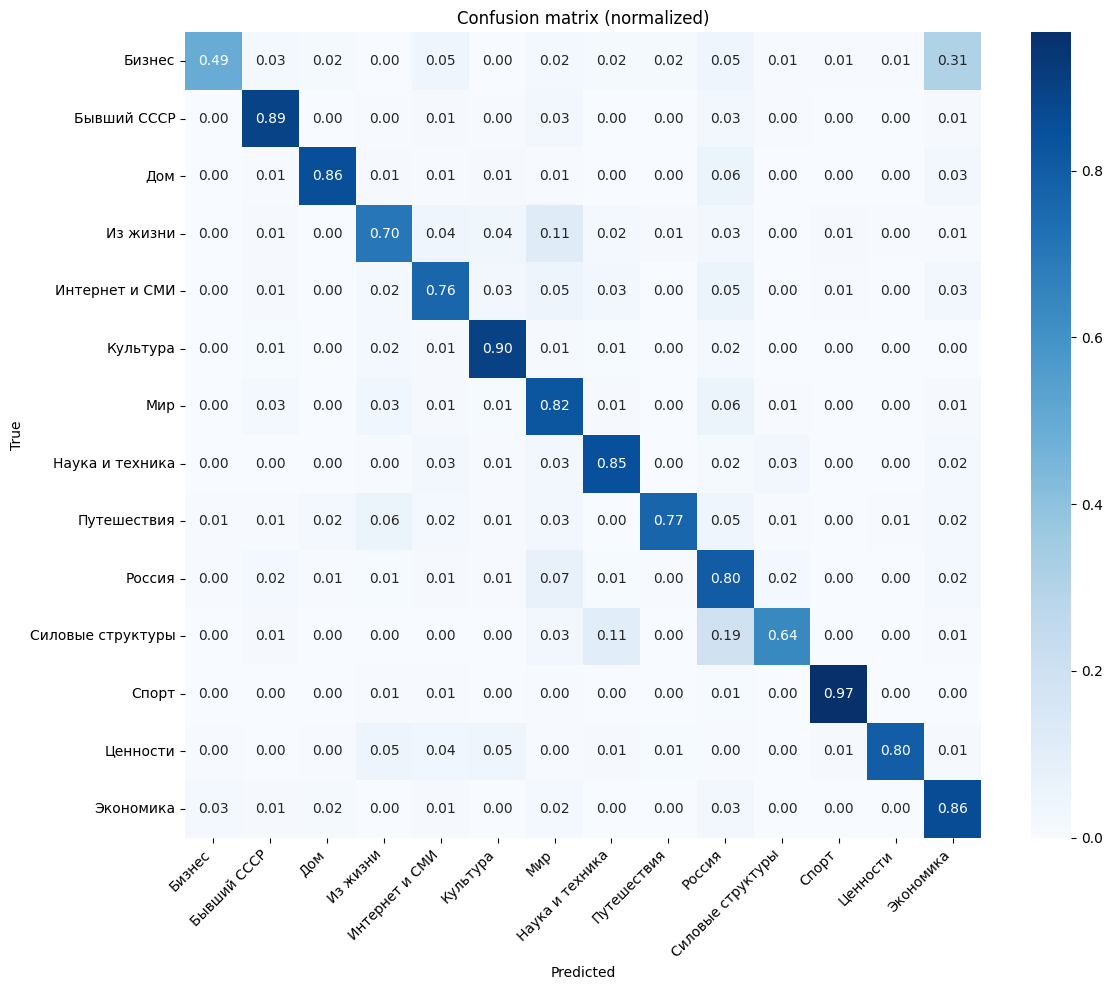

In [56]:
tfidf_proba = eval_model(pipe_tfidf, X_test, y_test)

### Выводы

На confusion matrix видно, откуда берутся ошибки модели:
1. Путает топики "Бизнес" и "Экономика"
2. "Россия" и "Силовые структуры"
3. "Из жизни" и "Мир" 
4. "Силовые структуры" и "Наука и техника"
5. Дисбаланс схожих классов также может повышать вероятность ошибки - например, тот факт что в обучающей выборке 10к строк "Экономика" и 1к строк "Бизнес" 

Во многом, заблуждения модели обоснованы. Закрыть их перебором гиперпараметров и дальнейшим обучением врядли получится - нужно:
1. Или переосмыслить разметку классов (т.к. "Бизнес" и "Экономика" довольно близки)
2. Или собрать больше данных для слабого класса